# Desafío - Introducción al Machine Learning
## Daniel Rojas López

### 1. Leer el archivo Retail_Invoices.xlsx y realizar un análisis de calidad de datos, para definir la calidad de la data entregada considerando valores anómalos, valores faltantes, etc. Limpia lo que sea necesario y realiza un análisis exploratorio de los datos considerando gráficos de distribuciones y correlaciones entre estos.

=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: 22190 filas, 6 columnas

Primeras filas:
  InvoiceNo InvoiceDate  CustomerID  Quantity  price_total  StockCode
0    536365  2010-12-01       17850        40       139.12          7
1    536366  2010-12-01       17850        12        22.20          2
2    536367  2010-12-01       13047        83       278.73         12
3    536368  2010-12-01       13047        15        70.05          4
4    536369  2010-12-01       13047         3        17.85          1

Tipos de datos:
InvoiceNo              object
InvoiceDate    datetime64[ns]
CustomerID              int64
Quantity                int64
price_total           float64
StockCode               int64
dtype: object

Estadísticas descriptivas:
                         InvoiceDate    CustomerID      Quantity  \
count                          22190  22190.000000  22190.000000   
mean   2011-06-29 05:59:15.223073536  15238.498738    221.130599   
min              2010-12-01 00:00:00  12346

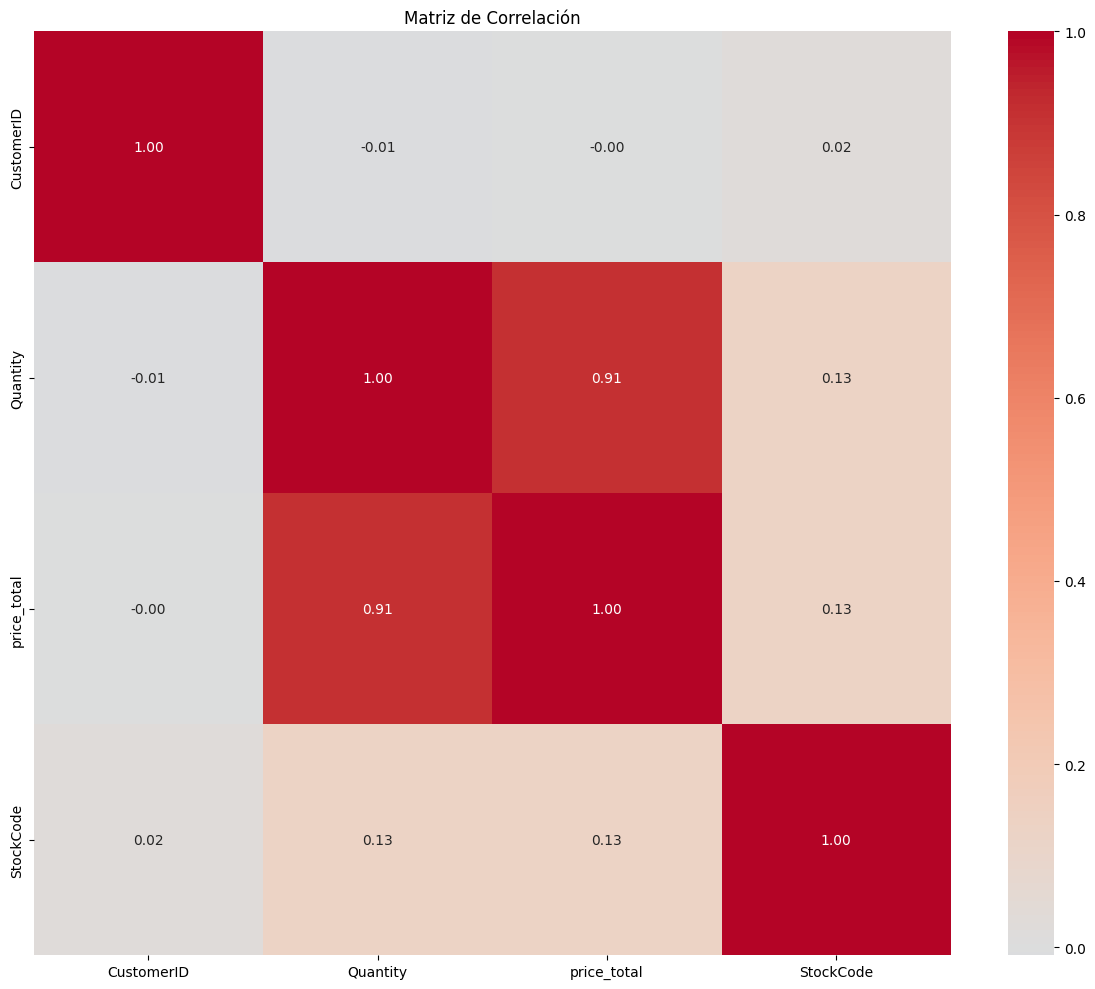

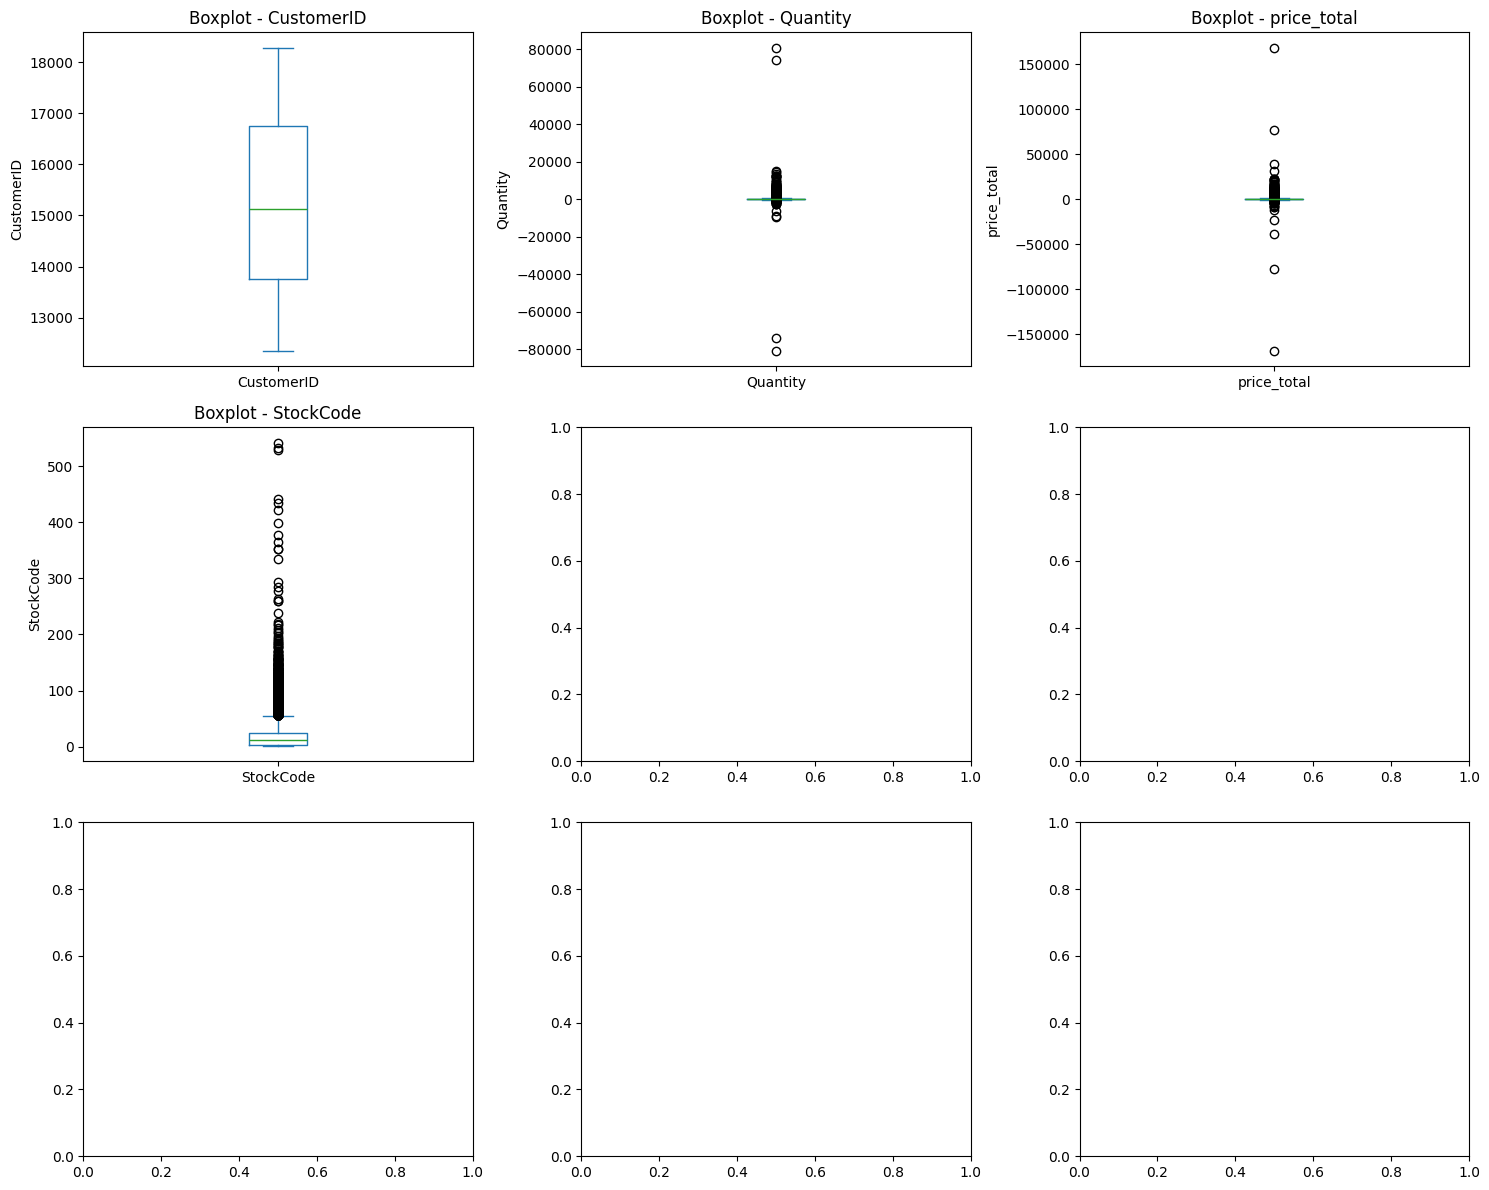

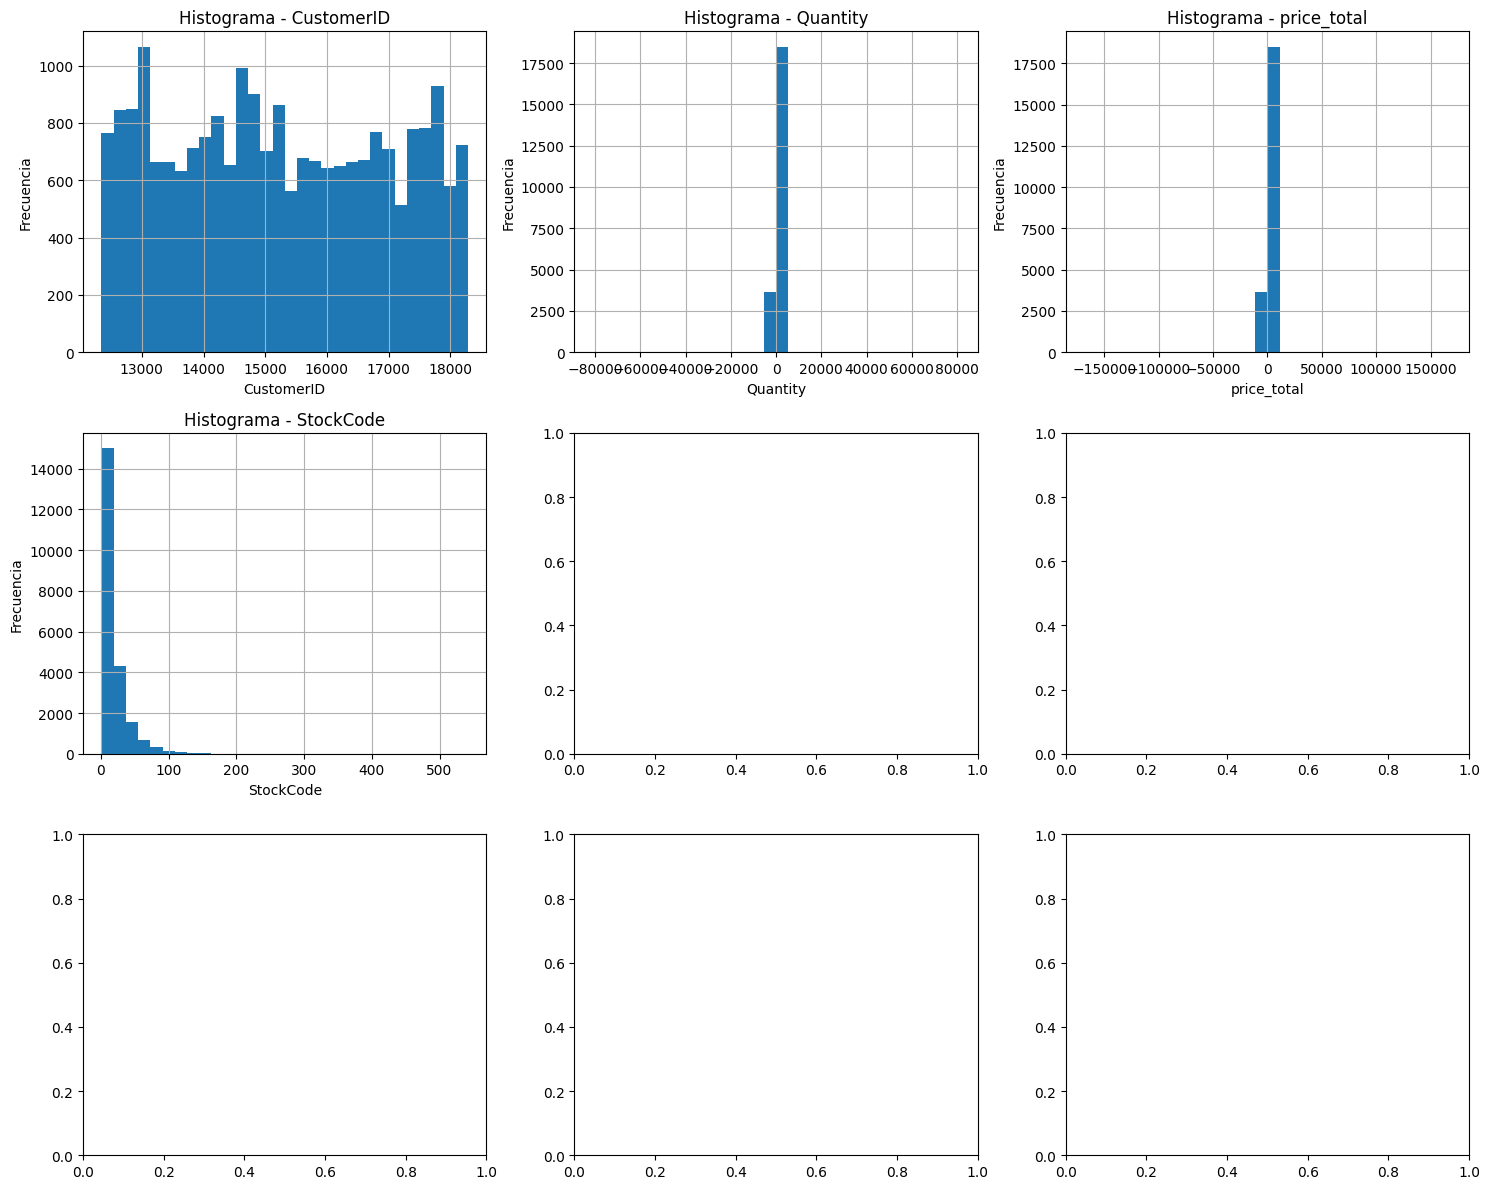


=== RESUMEN ===
El análisis de calidad de datos ha sido completado.
Se han identificado valores nulos, outliers y correlaciones entre variables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo Retail_Invoices.xlsx
df = pd.read_excel('Retail_Invoices.xlsx')

# Mostrar las primeras filas y dimensiones
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nPrimeras filas:")
print(df.head())
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nEstadísticas descriptivas:")
print(df.describe())

# Análisis de valores nulos
print("\n=== ANÁLISIS DE VALORES NULOS ===")
valores_nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(valores_nulos)
print(f"\nPorcentaje de valores nulos:")
print((valores_nulos / len(df) * 100).round(2))

# Análisis de datos atípicos (outliers) usando el método IQR
print("\n=== ANÁLISIS DE DATOS ATÍPICOS (OUTLIERS) ===")
columnas_numericas = df.select_dtypes(include=[np.number]).columns

for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"\n{col}:")
    print(f"  - Límite inferior: {limite_inferior:.2f}")
    print(f"  - Límite superior: {limite_superior:.2f}")
    print(f"  - Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Análisis de datos extraños (valores fuera de rangos lógicos)
print("\n=== ANÁLISIS DE DATOS EXTRAÑOS ===")
print("Verificación de rangos lógicos:")
for col in columnas_numericas:
    negativos = (df[col] < 0).sum()
    if negativos > 0:
        print(f"  - {col} negativos: {negativos}")

# Análisis de correlaciones
print("\n=== ANÁLISIS DE CORRELACIONES ===")
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()
print("Matriz de correlación:")
print(matriz_correlacion)

# Visualización de correlaciones
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# Visualización de distribuciones y outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(columnas_numericas):
    if i < 9:
        df[col].plot(kind='box', ax=axes[i])
        axes[i].set_title(f'Boxplot - {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Visualización de distribuciones (histogramas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(columnas_numericas):
    if i < 9:
        df[col].hist(ax=axes[i], bins=30)
        axes[i].set_title(f'Histograma - {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\n=== RESUMEN ===")
print("El análisis de calidad de datos ha sido completado.")
print("Se han identificado valores nulos, outliers y correlaciones entre variables.")

### 2. Generar variables para la segmentación. Notar que la granularidad de la data es por boleta y se necesita segmentar clientes, por lo que es necesario generar variables a nivel de clientes. Se propone generar al menos RFM (Recencia, frecuencia y monto).

In [2]:
# Generar variables RFM (Recency, Frequency, Monetary) a nivel de cliente

# Primero, ver las columnas disponibles para identificar las necesarias
print("Columnas disponibles:")
print(df.columns.tolist())

# Identificar columnas clave basadas en nombres comunes
customer_col = None
date_col = None
amount_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'customer' in col_lower or 'client' in col_lower or 'id' in col_lower:
        customer_col = col
    if 'date' in col_lower or 'time' in col_lower:
        date_col = col
    if 'amount' in col_lower or 'price' in col_lower or 'total' in col_lower or 'quantity' in col_lower:
        amount_col = col

print(f"\nColumnas identificadas automáticamente:")
print(f"Cliente: {customer_col}")
print(f"Fecha: {date_col}")
print(f"Monto: {amount_col}")

# Convertir fecha a datetime si es necesario
if date_col and df[date_col].dtype != 'datetime64[ns]':
    df[date_col] = pd.to_datetime(df[date_col])

# Calcular fecha de referencia (fecha más reciente en los datos + 1 día)
fecha_referencia = df[date_col].max() + pd.Timedelta(days=1)
print(f"\nFecha de referencia: {fecha_referencia}")

# Generar variables RFM
if customer_col and date_col and amount_col:
    # Recency: días desde la última compra del cliente
    recency = df.groupby(customer_col)[date_col].max().reset_index()
    recency.columns = [customer_col, 'UltimaCompra']
    recency['Recency'] = (fecha_referencia - recency['UltimaCompra']).dt.days
    
    # Frequency: número de compras del cliente
    frequency = df.groupby(customer_col).size().reset_index()
    frequency.columns = [customer_col, 'Frequency']
    
    # Monetary: monto total gastado por el cliente
    monetary = df.groupby(customer_col)[amount_col].sum().reset_index()
    monetary.columns = [customer_col, 'Monetary']
    
    # Combinar las tres métricas
    rfm = recency[[customer_col, 'Recency']].merge(frequency, on=customer_col)
    rfm = rfm.merge(monetary, on=customer_col)
    
    print(f"\n=== VARIABLES RFM GENERADAS ===")
    print(f"Número de clientes únicos: {len(rfm)}")
    print(f"\nPrimeras filas del dataset RFM:")
    print(rfm.head(10))
    
    print(f"\nEstadísticas descriptivas de RFM:")
    print(rfm.describe())
    
    # Guardar el dataframe RFM
    df_rfm = rfm
    print("\nDataset RFM guardado en variable 'df_rfm'")
    
else:
    print("\nNo se pudieron identificar todas las columnas necesarias.")
    print("Por favor, especifique manualmente las columnas para:")
    print("- ID de cliente")
    print("- Fecha de compra")
    print("- Monto de la compra")

Columnas disponibles:
['InvoiceNo', 'InvoiceDate', 'CustomerID', 'Quantity', 'price_total', 'StockCode']

Columnas identificadas automáticamente:
Cliente: CustomerID
Fecha: InvoiceDate
Monto: price_total

Fecha de referencia: 2011-12-10 00:00:00

=== VARIABLES RFM GENERADAS ===
Número de clientes únicos: 4372

Primeras filas del dataset RFM:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          2      0.00
1       12347        3          7   4310.00
2       12348       76          4   1797.24
3       12349       19          1   1757.55
4       12350      311          1    334.40
5       12352       37         11   1545.41
6       12353      205          1     89.00
7       12354      233          1   1079.40
8       12355      215          1    459.40
9       12356       23          3   2811.43

Estadísticas descriptivas de RFM:
         CustomerID      Recency    Frequency       Monetary
count   4372.000000  4372.000000  4372.000000    4372.000000
mean   15299.67

### 3. Realizar un análisis exploratorio y las transformaciones necesarias las nuevas variables.

=== ANÁLISIS EXPLORATORIO DE VARIABLES RFM ===
   CustomerID  Recency  Frequency  Monetary
0       12346      326          2      0.00
1       12347        3          7   4310.00
2       12348       76          4   1797.24
3       12349       19          1   1757.55
4       12350      311          1    334.40
5       12352       37         11   1545.41
6       12353      205          1     89.00
7       12354      233          1   1079.40
8       12355      215          1    459.40
9       12356       23          3   2811.43

Dimensiones del dataset RFM: (4372, 4)

Tipos de datos:
CustomerID      int64
Recency         int64
Frequency       int64
Monetary      float64
dtype: object

Estadísticas descriptivas:
         CustomerID      Recency    Frequency       Monetary
count   4372.000000  4372.000000  4372.000000    4372.000000
mean   15299.677722    92.581199     5.075480    1898.459701
std     1722.390705   100.772139     9.338754    8219.345141
min    12346.000000     1.000000     1

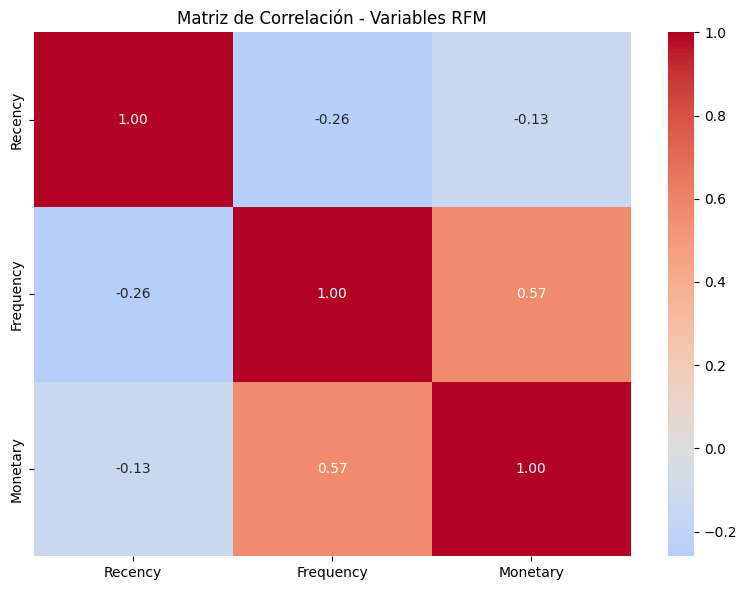

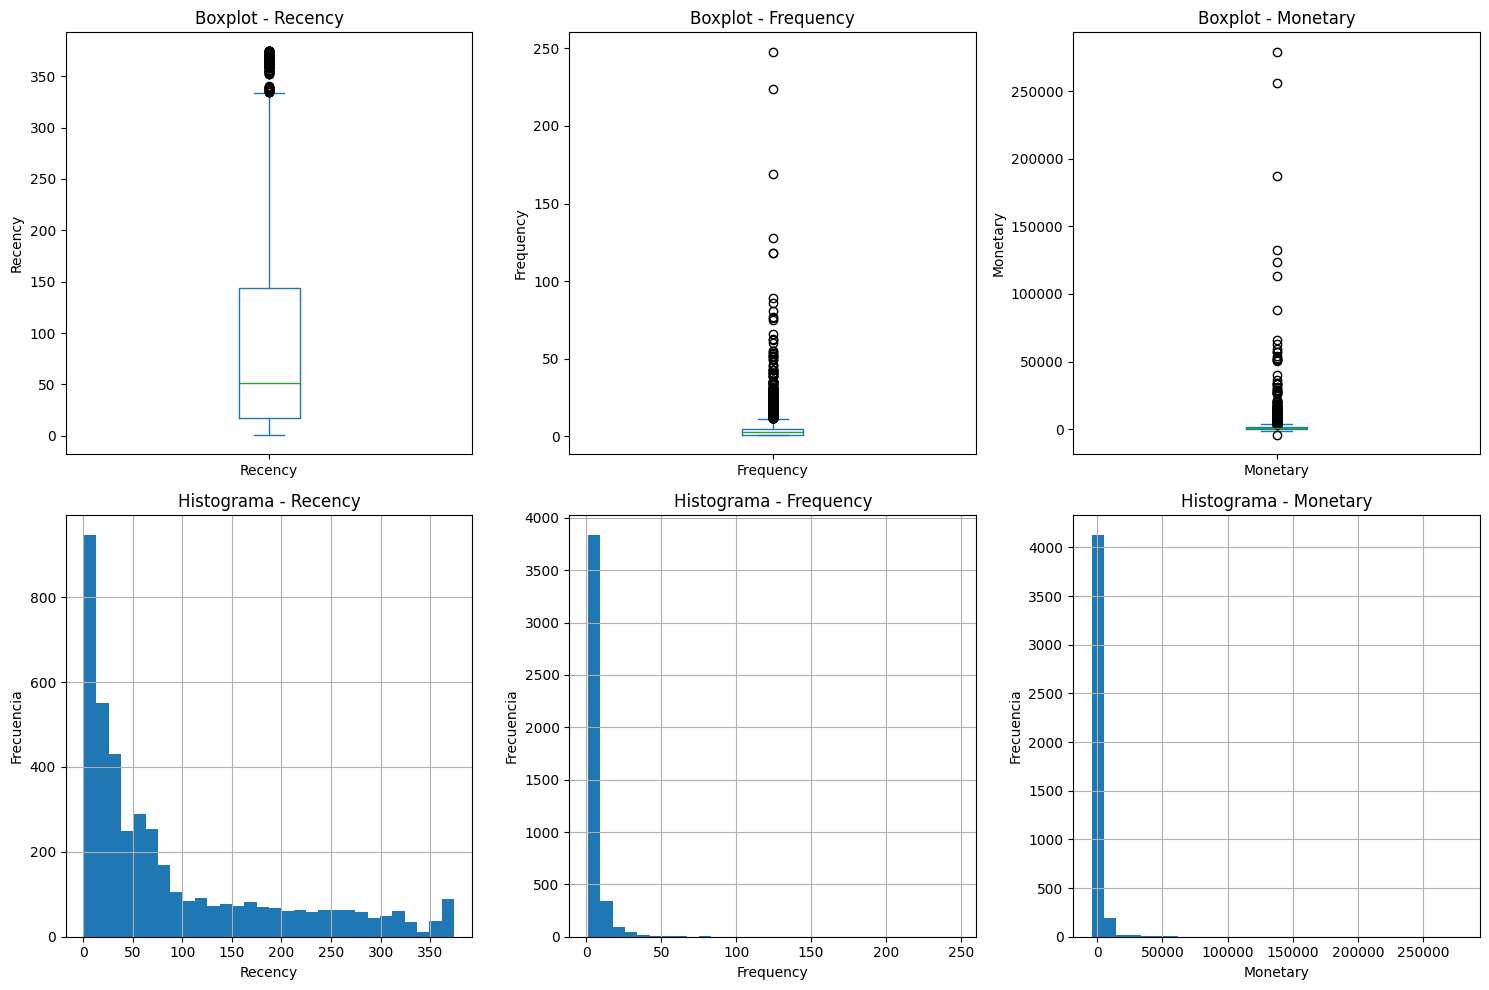


=== ANÁLISIS DE SESGO (SKEWNESS) ===
Recency: 1.2489
  - Distribución muy sesgada, se recomienda transformación
Frequency: 11.4084
  - Distribución muy sesgada, se recomienda transformación
Monetary: 21.6978
  - Distribución muy sesgada, se recomienda transformación

=== TRANSFORMACIONES ===
Clientes eliminados por Monetary negativo: 41
Clientes restantes: 4331

Variables transformadas:
   Recency  Frequency  Monetary  Frequency_log  Monetary_log
0      326          2      0.00       1.098612      0.000000
1        3          7   4310.00       2.079442      8.368925
2       76          4   1797.24       1.609438      7.494564
3       19          1   1757.55       0.693147      7.472245
4      311          1    334.40       0.693147      5.815324
5       37         11   1545.41       2.484907      7.343691
6      205          1     89.00       0.693147      4.499810
7      233          1   1079.40       0.693147      6.985087
8      215          1    459.40       0.693147      6.132096

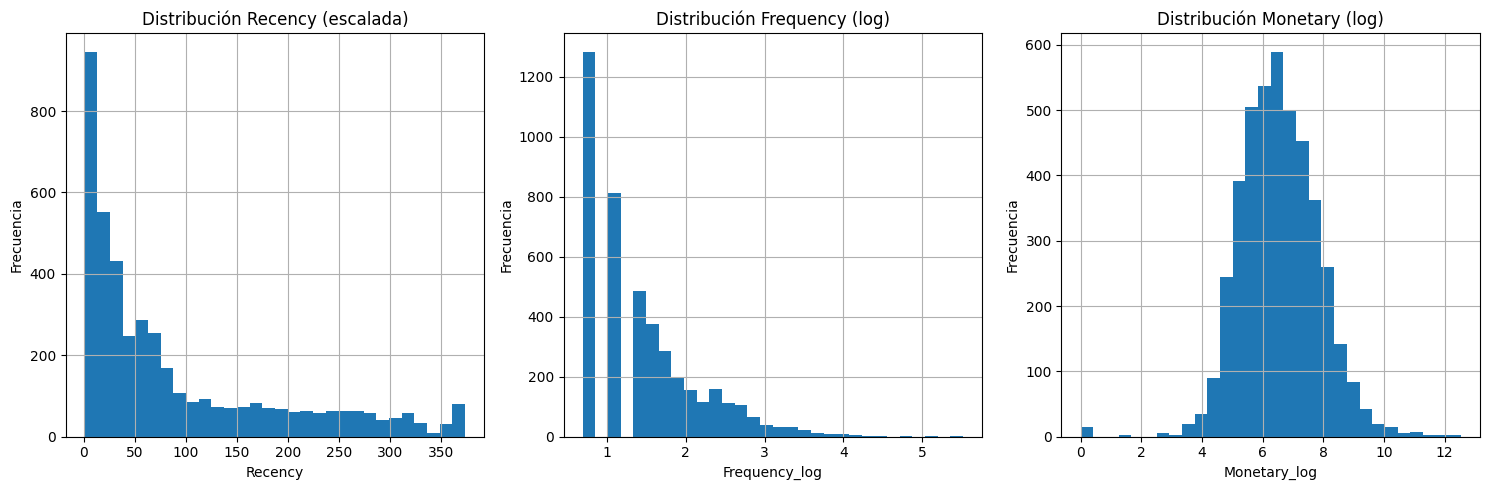


=== ESCALADO DE VARIABLES PARA CLUSTERING ===
Variables escaladas (media=0, desviación estándar=1):
   Recency_scaled  Frequency_log  Monetary_log
0        2.372133      -0.474459     -5.053011
1       -0.886834       0.856233      1.401764
2       -0.150288       0.218579      0.727388
3       -0.725400      -1.024553      0.710174
4        2.220788      -1.024553     -0.567774
5       -0.543785       1.406328      0.611023
6        1.151282      -1.024553     -1.582403
7        1.433793      -1.024553      0.334439
8        1.252178      -1.024553     -0.323455
9       -0.685041      -0.084160      1.072335

Estadísticas después del escalado:
       Recency_scaled  Frequency_log  Monetary_log
count    4.331000e+03   4.331000e+03  4.331000e+03
mean    -1.148418e-17  -4.265553e-17 -1.968717e-17
std      1.000115e+00   1.000115e+00  1.000115e+00
min     -9.070138e-01  -1.024553e+00 -5.053011e+00
25%     -7.455789e-01  -1.024553e+00 -6.489728e-01
50%     -4.126194e-01  -8.416014e-02 -4.

In [3]:
# Análisis exploratorio y transformaciones de las variables RFM

print("=== ANÁLISIS EXPLORATORIO DE VARIABLES RFM ===")
print(df_rfm.head(10))
print(f"\nDimensiones del dataset RFM: {df_rfm.shape}")
print(f"\nTipos de datos:")
print(df_rfm.dtypes)
print(f"\nEstadísticas descriptivas:")
print(df_rfm.describe())

# Análisis de valores nulos en RFM
print("\n=== ANÁLISIS DE VALORES NULOS ===")
valores_nulos_rfm = df_rfm.isnull().sum()
print("Valores nulos por columna:")
print(valores_nulos_rfm)

# Análisis de valores negativos en Monetary
print("\n=== ANÁLISIS DE VALORES NEGATIVOS ===")
monetary_negativos = (df_rfm['Monetary'] < 0).sum()
print(f"Clientes con Monetary negativo: {monetary_negativos}")
if monetary_negativos > 0:
    print(f"Porcentaje: {monetary_negativos/len(df_rfm)*100:.2f}%")
    print("\nClientes con Monetary negativo:")
    print(df_rfm[df_rfm['Monetary'] < 0].head(10))

# Análisis de outliers en RFM usando IQR
print("\n=== ANÁLISIS DE OUTLIERS EN RFM ===")
columnas_rfm = ['Recency', 'Frequency', 'Monetary']

for col in columnas_rfm:
    Q1 = df_rfm[col].quantile(0.25)
    Q3 = df_rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df_rfm[(df_rfm[col] < limite_inferior) | (df_rfm[col] > limite_superior)]
    print(f"\n{col}:")
    print(f"  - Límite inferior: {limite_inferior:.2f}")
    print(f"  - Límite superior: {limite_superior:.2f}")
    print(f"  - Outliers detectados: {len(outliers)} ({len(outliers)/len(df_rfm)*100:.2f}%)")

# Análisis de correlaciones entre variables RFM
print("\n=== ANÁLISIS DE CORRELACIONES RFM ===")
matriz_correlacion_rfm = df_rfm[columnas_rfm].corr()
print("Matriz de correlación:")
print(matriz_correlacion_rfm)

# Visualización de correlaciones RFM
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion_rfm, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables RFM')
plt.tight_layout()
plt.show()

# Visualización de distribuciones RFM
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Boxplots
for i, col in enumerate(columnas_rfm):
    df_rfm[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}')
    axes[i].set_ylabel(col)

# Histogramas
for i, col in enumerate(columnas_rfm):
    df_rfm[col].hist(ax=axes[i+3], bins=30)
    axes[i+3].set_title(f'Histograma - {col}')
    axes[i+3].set_xlabel(col)
    axes[i+3].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Análisis de sesgo (skewness)
print("\n=== ANÁLISIS DE SESGO (SKEWNESS) ===")
from scipy.stats import skew
for col in columnas_rfm:
    skewness = skew(df_rfm[col])
    print(f"{col}: {skewness:.4f}")
    if abs(skewness) > 1:
        print(f"  - Distribución muy sesgada, se recomienda transformación")

# Transformaciones necesarias
print("\n=== TRANSFORMACIONES ===")

# 1. Eliminar clientes con Monetary negativo (devoluciones)
df_rfm_clean = df_rfm[df_rfm['Monetary'] >= 0].copy()
print(f"Clientes eliminados por Monetary negativo: {len(df_rfm) - len(df_rfm_clean)}")
print(f"Clientes restantes: {len(df_rfm_clean)}")

# 2. Aplicar log-transform a Frequency y Monetary debido al alto sesgo
df_rfm_transformed = df_rfm_clean.copy()
df_rfm_transformed['Frequency_log'] = np.log1p(df_rfm_transformed['Frequency'])
df_rfm_transformed['Monetary_log'] = np.log1p(df_rfm_transformed['Monetary'])

# Recency no necesita transformación (distribución más normal)
df_rfm_transformed['Recency_scaled'] = df_rfm_transformed['Recency']

print("\nVariables transformadas:")
print(df_rfm_transformed[['Recency', 'Frequency', 'Monetary', 'Frequency_log', 'Monetary_log']].head(10))

# Verificar el efecto de las transformaciones
print("\n=== SESGO DESPUÉS DE TRANSFORMACIONES ===")
for col in ['Frequency_log', 'Monetary_log']:
    skewness = skew(df_rfm_transformed[col])
    print(f"{col}: {skewness:.4f}")

# Visualización de distribuciones después de transformaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency (sin transformación)
df_rfm_transformed['Recency_scaled'].hist(ax=axes[0], bins=30)
axes[0].set_title('Distribución Recency (escalada)')
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Frecuencia')

# Frequency log-transformed
df_rfm_transformed['Frequency_log'].hist(ax=axes[1], bins=30)
axes[1].set_title('Distribución Frequency (log)')
axes[1].set_xlabel('Frequency_log')
axes[1].set_ylabel('Frecuencia')

# Monetary log-transformed
df_rfm_transformed['Monetary_log'].hist(ax=axes[2], bins=30)
axes[2].set_title('Distribución Monetary (log)')
axes[2].set_xlabel('Monetary_log')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Escalado de variables para clustering (StandardScaler)
from sklearn.preprocessing import StandardScaler

print("\n=== ESCALADO DE VARIABLES PARA CLUSTERING ===")
variables_para_clustering = ['Recency_scaled', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
df_rfm_scaled = df_rfm_transformed[variables_para_clustering].copy()
df_rfm_scaled[variables_para_clustering] = scaler.fit_transform(df_rfm_scaled[variables_para_clustering])

print("Variables escaladas (media=0, desviación estándar=1):")
print(df_rfm_scaled.head(10))
print(f"\nEstadísticas después del escalado:")
print(df_rfm_scaled.describe())

# Guardar el dataset transformado y escalado
df_rfm_final = df_rfm_transformed.copy()
df_rfm_final[variables_para_clustering] = df_rfm_scaled[variables_para_clustering].values

print("\n=== RESUMEN ===")
print(f"Dataset original RFM: {len(df_rfm)} clientes")
print(f"Dataset después de limpieza: {len(df_rfm_clean)} clientes")
print(f"Dataset transformado y escalado: {len(df_rfm_final)} clientes")
print("\nTransformaciones aplicadas:")
print("1. Eliminación de clientes con Monetary negativo")
print("2. Log-transform en Frequency y Monetary")
print("3. Escalado StandardScaler en todas las variables")
print("\nDataset final guardado en variable 'df_rfm_final'")

### 4.Aplicar al menos 2 algoritmos de clustering. Buscar el número indicado de clusters que puedan tener y visualizar los cluster resultantes de los algoritmos.

In [ ]:
# Aplicación de algoritmos de clustering

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("=== CLUSTERING CON K-MEANS ===")

# Variables para clustering (ya escaladas)
X = df_rfm_final[['Recency_scaled', 'Frequency_log', 'Monetary_log']].values
print(f"Dimensiones del dataset para clustering: {X.shape}")

# 1. Búsqueda del número óptimo de clusters usando el método del codo
print("\n=== MÉTODO DEL CODO PARA K-MEANS ===")
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Visualización del método del codo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Mostrar resultados
print("\nResultados del método del codo:")
for k, inertia, sil in zip(K_range, inertias, silhouette_scores):
    print(f"k={k}: Inercia={inertia:.2f}, Silhouette={sil:.4f}")

# Seleccionar k óptimo (basado en silhouette score)
k_optimo = K_range[np.argmax(silhouette_scores)]
print(f"\nNúmero óptimo de clusters según Silhouette: {k_optimo}")

# 2. Aplicar K-Means con k óptimo
print(f"\n=== APLICANDO K-MEANS CON k={k_optimo} ===")
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_rfm_final['Cluster_KMeans'] = kmeans_final.fit_predict(X)

print(f"Clusters asignados:")
print(df_rfm_final['Cluster_KMeans'].value_counts().sort_index())

# 3. Clustering Jerárquico (Agglomerative)
print("\n=== CLUSTERING JERÁRQUICO (AGGLOMERATIVE) ===")

# Búsqueda del número óptimo de clusters para clustering jerárquico
silhouette_scores_agg = []

for k in K_range:
    agg_clustering = AgglomerativeClustering(n_clusters=k)
    labels = agg_clustering.fit_predict(X)
    silhouette_scores_agg.append(silhouette_score(X, labels))

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores_agg, 'go-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Clustering Jerárquico')
plt.grid(True)
plt.show()

print("\nResultados Silhouette Score - Clustering Jerárquico:")
for k, sil in zip(K_range, silhouette_scores_agg):
    print(f"k={k}: Silhouette={sil:.4f}")

k_optimo_agg = K_range[np.argmax(silhouette_scores_agg)]
print(f"\nNúmero óptimo de clusters según Silhouette: {k_optimo_agg}")

# Aplicar clustering jerárquico con k óptimo
print(f"\n=== APLICANDO CLUSTERING JERÁRQUICO CON k={k_optimo_agg} ===")
agg_final = AgglomerativeClustering(n_clusters=k_optimo_agg)
df_rfm_final['Cluster_Agg'] = agg_final.fit_predict(X)

print(f"Clusters asignados:")
print(df_rfm_final['Cluster_Agg'].value_counts().sort_index())

# 4. Visualización de los clusters (usando PCA para reducción de dimensionalidad)
from sklearn.decomposition import PCA

print("\n=== VISUALIZACIÓN DE CLUSTERS CON PCA ===")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Crear figura con subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means
scatter_kmeans = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                                 c=df_rfm_final['Cluster_KMeans'], 
                                 cmap='viridis', alpha=0.6)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].set_title(f'Clusters K-Means (k={k_optimo})')
plt.colorbar(scatter_kmeans, ax=axes[0], label='Cluster')

# Clustering Jerárquico
scatter_agg = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                              c=df_rfm_final['Cluster_Agg'], 
                              cmap='viridis', alpha=0.6)
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].set_title(f'Clusters Jerárquico (k={k_optimo_agg})')
plt.colorbar(scatter_agg, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# 5. Visualización de clusters por pares de variables RFM
print("\n=== VISUALIZACIÓN DE CLUSTERS POR VARIABLES RFM ===")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# K-Means - Recency vs Frequency
scatter1 = axes[0, 0].scatter(df_rfm_final['Recency'], df_rfm_final['Frequency'], 
                             c=df_rfm_final['Cluster_KMeans'], cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Recency')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('K-Means: Recency vs Frequency')
plt.colorbar(scatter1, ax=axes[0, 0])

# K-Means - Recency vs Monetary
scatter2 = axes[0, 1].scatter(df_rfm_final['Recency'], df_rfm_final['Monetary'], 
                             c=df_rfm_final['Cluster_KMeans'], cmap='viridis', alpha=0.6)
axes[0, 1].set_xlabel('Recency')
axes[0, 1].set_ylabel('Monetary')
axes[0, 1].set_title('K-Means: Recency vs Monetary')
plt.colorbar(scatter2, ax=axes[0, 1])

# K-Means - Frequency vs Monetary
scatter3 = axes[0, 2].scatter(df_rfm_final['Frequency'], df_rfm_final['Monetary'], 
                             c=df_rfm_final['Cluster_KMeans'], cmap='viridis', alpha=0.6)
axes[0, 2].set_xlabel('Frequency')
axes[0, 2].set_ylabel('Monetary')
axes[0, 2].set_title('K-Means: Frequency vs Monetary')
plt.colorbar(scatter3, ax=axes[0, 2])

# Clustering Jerárquico - Recency vs Frequency
scatter4 = axes[1, 0].scatter(df_rfm_final['Recency'], df_rfm_final['Frequency'], 
                             c=df_rfm_final['Cluster_Agg'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('Recency')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Jerárquico: Recency vs Frequency')
plt.colorbar(scatter4, ax=axes[1, 0])

# Clustering Jerárquico - Recency vs Monetary
scatter5 = axes[1, 1].scatter(df_rfm_final['Recency'], df_rfm_final['Monetary'], 
                             c=df_rfm_final['Cluster_Agg'], cmap='viridis', alpha=0.6)
axes[1, 1].set_xlabel('Recency')
axes[1, 1].set_ylabel('Monetary')
axes[1, 1].set_title('Jerárquico: Recency vs Monetary')
plt.colorbar(scatter5, ax=axes[1, 1])

# Clustering Jerárquico - Frequency vs Monetary
scatter6 = axes[1, 2].scatter(df_rfm_final['Frequency'], df_rfm_final['Monetary'], 
                             c=df_rfm_final['Cluster_Agg'], cmap='viridis', alpha=0.6)
axes[1, 2].set_xlabel('Frequency')
axes[1, 2].set_ylabel('Monetary')
axes[1, 2].set_title('Jerárquico: Frequency vs Monetary')
plt.colorbar(scatter6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# 6. Comparación de métricas
print("\n=== COMPARACIÓN DE MÉTRICAS ===")
print(f"K-Means (k={k_optimo}):")
print(f"  - Silhouette Score: {max(silhouette_scores):.4f}")
print(f"  - Inercia: {inertias[k_optimo-2]:.2f}")

print(f"\nClustering Jerárquico (k={k_optimo_agg}):")
print(f"  - Silhouette Score: {max(silhouette_scores_agg):.4f}")

print("\n=== RESUMEN ===")
print(f"Algoritmos aplicados: K-Means y Clustering Jerárquico")
print(f"K óptimo K-Means: {k_optimo}")
print(f"K óptimo Jerárquico: {k_optimo_agg}")
print(f"Clusters guardados en df_rfm_final['Cluster_KMeans'] y df_rfm_final['Cluster_Agg']")

### 5.Evaluar la calidad de los clustering de forma numérica y realizar una explicación de cada segmento asignándoles un nombre descriptivo